In [2]:
!pip install requests

In [1]:
import requests
import os

url = "https://api.together.xyz/v1/chat/completions"

payload = {
    "model": "mistralai/Mixtral-8x7B-Instruct-v0.1",
    "max_tokens": 512,
    "stop": ["</s>", "[/INST]"],
    "temperature": 0.7,
    "top_p": 0.7,
    "top_k": 50,
    "repetition_penalty": 1,
    "messages": [
        {
            "role": "system",
            "content": "You are a helpful travel agent"
        },
        {
            "role": "user",
            "content": "Tell me about San Francisco"
        }
    ]
}

# if "TOGETHER_API_KEY" not in os.environ:
#     os.environ["TOGETHER_API_KEY"] = os.getenv('TOGETHER_API_KEY')
print(os.getenv('TOGETHER_API_KEY'))
headers = {
    "accept": "application/json",
    "content-type": "application/json",
    "Authorization": os.getenv('TOGETHER_API_KEY')
}

response = requests.post(url, json=payload, headers=headers)

print(response.text)

/Users/yanyifu/Documents/_Coding/LLM Predict Stock/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Bearer 86ccf39999edda3e0a2f51a139bda1c5f9dfdaa12047b180bd886763da9e013d
{"id":"889410eee9896a87-TPE","object":"chat.completion","created":1716624808,"model":"mistralai/Mixtral-8x7B-Instruct-v0.1","prompt":[],"choices":[{"finish_reason":"eos","logprobs":null,"index":0,"message":{"role":"assistant","content":" San Francisco is a vibrant and culturally rich city located in Northern California. It is known for its cool summer fog, steep rolling hills, and landmarks including the Golden Gate Bridge, cable cars, and Chinatown.\n\nThe Golden Gate Bridge is a suspension bridge spanning the Golden Gate strait, and is one of the most internationally recognized symbols of San Francisco and California. It is a popular tourist attraction and offers breathtaking views of the San Francisco Bay and the Pacific Ocean.\n\nThe city's cable car system is the world's last manually operated cable car system, and is a National Historic Landmark. It is a fun and unique way to get around the city and offers st

# 一開始用gemini 評分的程式

In [177]:
import csv
import os
import pandas as pd
import numpy as np

stock_id = "2912"

# 讀取評分-----------------------------
folder_path = "stock_news/"+stock_id+"/"+stock_id+"_response"

# 獲取文件夾中的所有文件名列表
files = os.listdir(folder_path)
sorted_files = sorted(files)
response = []

for i in range(len(sorted_files)):
    with open(folder_path + "/" + sorted_files[i], "r") as f:
        try:
            data = f.read()
            # print(data)
            response.append([sorted_files[i].split('_')[1], data])
        except:
            pass

response_np = np.array(response)

# 讀取價格-----------------------------
df_csv = pd.read_csv("price_history/"+stock_id+"_price.csv")
price = df_csv.to_numpy()

for i in range(len(price)):
    original_date = price[i][0]
    # 提取年份、月份和日期部分
    year = '20' + original_date[1:3]  # 從索引 0 到索引 2，不包括索引 2
    month = original_date[4:6]  # 從索引 3 到索引 5，不包括索引 5
    day = original_date[7:]  # 從索引 6 到字符串的結尾
    # 將提取的部分組合為新的日期格式
    formatted_date = year + month + day
    price[i][0] = formatted_date
    
price_np = np.flip(np.array(price), axis=0)

# print(response_np)
# print(len(response_np))
# print(price_np)
# print(len(price_np))

# 合併-----------------------------
price_with_signal = []
signal = 0
for i, itemi in enumerate(price_np):
    for j, itemj in enumerate(response_np):
        if itemi[0] == itemj[0]:
            if i < len(price_np)-1:
                price_with_signal.append([itemi[0], price_np[i + 1,1], itemj[1]])
            # try:
            #     price_with_signal.append([itemi[0], price_np[i + 1,1], int(itemj[1])])
            # except:
            #     pass
            
print(price_with_signal)

# 指定要寫入的檔案路徑
csv_file_path = "stock_news/"+stock_id+"/"+stock_id+"_signal.csv"

# 開啟 CSV 檔案並寫入資料
with open(csv_file_path, 'w') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerows(price_with_signal)

print(f'Data has been written to {csv_file_path}')

[['20220322', 261.0, '50'], ['20220324', 262.0, '抱歉，由於我沒有收到任何文章，因此無法為其打分。'], ['20220325', 260.0, '50分（中立）\n\n這篇文章是一份公司交易公告，內容主要說明一筆不動產使用權資產的取得交易。公告中沒有明顯的情緒表達，因此評分為中立的50分。'], ['20220331', 262.0, '75分'], ['20220411', 265.0, '0'], ['20220418', 270.5, '75'], ['20220428', 272.0, '80'], ['20220429', 275.0, '85分'], ['20220504', 277.5, '50'], ['20220505', 274.5, '抱歉，您沒有提供任何文章供我評分。'], ['20220510', 264.0, '由於提供的文章中沒有任何情緒表達，因此無法打分。'], ['20220511', 264.5, '75'], ['20220523', 261.5, '70分'], ['20220525', 269.0, '70'], ['20220526', 270.0, '30'], ['20220530', 267.0, '60分\n\n這篇文章是關於一筆不動產使用權資產的交易，交易總金額約為 10 億元。交易內容包括交易單位數量、每單位價格、交易總金額、交易相對人、交易條件等資訊。文章的語氣平實，沒有明顯的情緒表達，因此打分為中立的 60 分。'], ['20220531', 271.0, '95'], ['20220601', 265.0, '85 分'], ['20220608', 265.5, '90'], ['20220610', 263.5, '無法評分，因為文章中沒有任何情緒內容。'], ['20220617', 262.0, '50'], ['20220623', 272.0, '50'], ['20220624', 274.0, '50'], ['20220627', 272.0, '抱歉，你沒有提供給我任何文章，所以我無法評分它的情緒。'], ['20220629', 270.0, '50'], ['20220630', 272.5, '80'], ['20220701'

In [179]:
#依照gemini評分買入
import pandas as pd

csv_file_path = "stock_news/"+stock_id+"/"+stock_id+"_signal_1.csv"
# 讀取CSV檔案為DataFrame
df = pd.read_csv(csv_file_path)

# 將DataFrame轉換為NumPy陣列
sig_data = df.to_numpy()

hold = 0
balance_in = 0
for item in sig_data:
    i2 = item[2]
    if i2 >90:
        balance_in += i2 * 1000
        hold = hold + ((i2 * 1000)/float(item[1]))

last_price = float(sig_data[len(sig_data)-1][1])
print("股票", stock_id)
print("總投入資金", balance_in)
print()
print("透過gemini回答")
print("期末市值", hold * last_price)
print("報酬率", hold * last_price/balance_in)
# print("20220321每股價格 69.2, 20240315 每股價格 92.7 漲幅1.33")

#以同樣的資金定期定額買入
from datetime import datetime

# 初始化變數來追蹤每個月的第一天
first_days = []
current_month = ''
for date_str, value in price_np:
    # 將日期字符串轉換為 datetime 對象
    date_obj = datetime.strptime(date_str, '%Y%m%d')
    # 提取月份
    month = date_obj.strftime('%Y%m')
    # 如果月份改變了，則將該日期添加到列表中
    if month != current_month:
        first_days.append([date_str, value])
        current_month = month



hold = 0
balance = balance_in/25
for item in first_days:
    hold = hold + balance/item[1]
print("-"*50)
print("以同樣的資金每月第一個交易日定期定額買入")
print("期末市值", hold* last_price)
print("報酬率", hold * last_price/balance_in)

股票 2912
總投入資金 290000.0

透過gemini回答
期末市值 291532.9265207215
報酬率 1.0052859535197294
--------------------------------------------------
以同樣的資金每月第一個交易日定期定額買入
期末市值 288539.04469533416
報酬率 0.9949622230873592


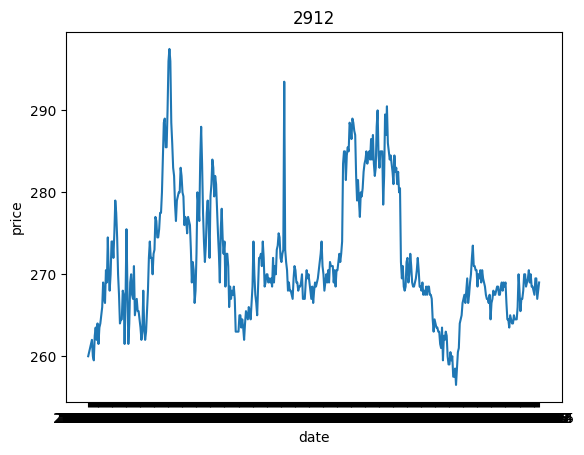

In [180]:
import matplotlib.pyplot as plt

dates = [row[0] for row in price_np]
values = [row[1] for row in price_np]

# 繪製折線圖
plt.plot(dates, values)

# 添加標籤和標題
plt.xlabel('date')
plt.ylabel('price')
plt.title(stock_id)



plt.show()
